[*********************100%***********************]  1 of 1 completed


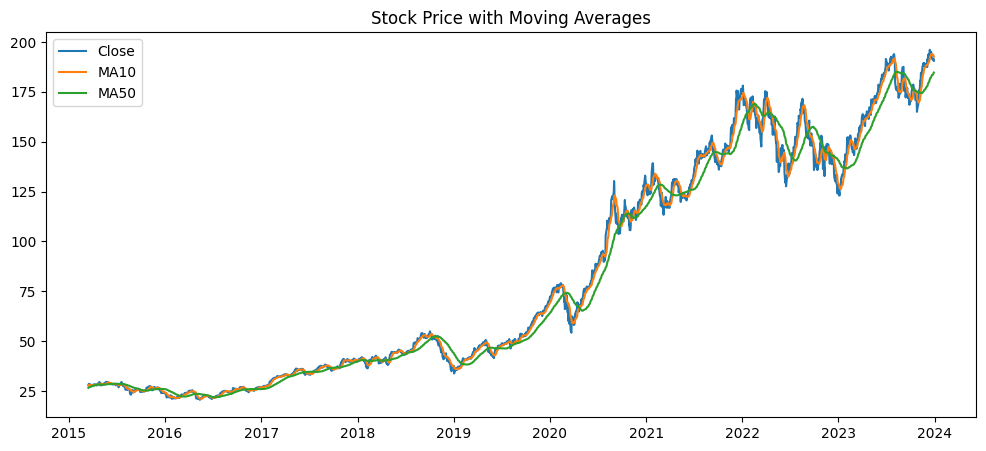


📊 MODEL PERFORMANCE
MAE  : 6.21
RMSE : 9.16
R²   : 0.7632

📋 SAMPLE PREDICTIONS:
   Actual Price  Predicted Price     Error
0    166.955276       163.038775  3.916502
1    161.948563       167.554789 -5.606226
2    161.733032       161.837634 -0.104602
3    164.015930       161.438256  2.577674
4    163.849380       162.017086  1.832294
5    163.055740       161.588825  1.466915
6    158.519348       161.545136 -3.025788
7    159.587326       158.554240  1.033086
8    153.630219       158.744326 -5.114107
9    153.404877       155.830799 -2.425922


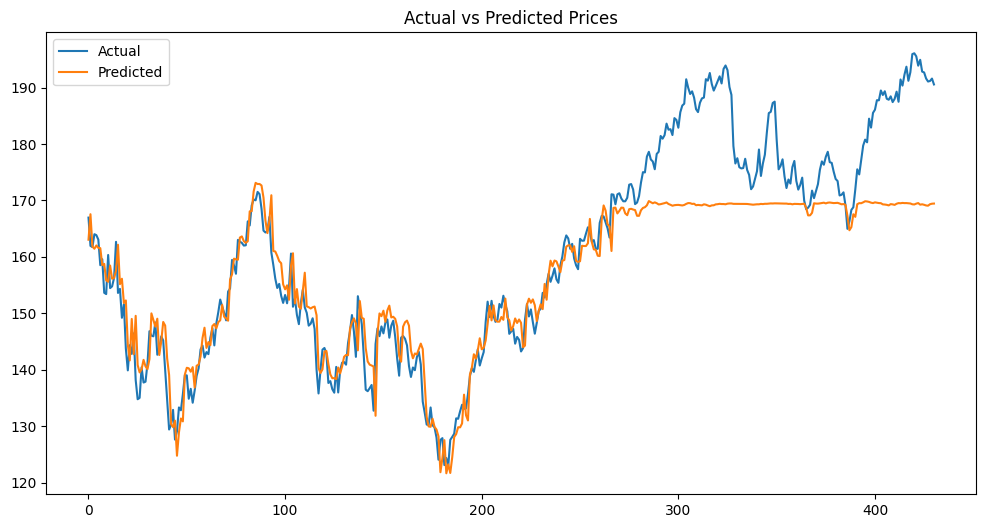


🔮 NEXT DAY PREDICTED PRICE:
Predicted Closing Price: $169.50

✅ Results saved to stock_predictions.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# 1. Download Data
# -----------------------------
df = yf.download('AAPL', start='2015-01-01', end='2024-01-01')
df.reset_index(inplace=True)
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

# -----------------------------
# 2. Feature Engineering (NEW)
# -----------------------------
df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

df.dropna(inplace=True)

# -----------------------------
# 3. Visualization
# -----------------------------
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], df['MA10'], label='MA10')
plt.plot(df['Date'], df['MA50'], label='MA50')
plt.legend()
plt.title("Stock Price with Moving Averages")
plt.show()

# -----------------------------
# 4. Preprocessing
# -----------------------------
features = df[['Close', 'MA10', 'MA50']].values

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(features)

# -----------------------------
# 5. Create Sequences
# -----------------------------
SEQ_LEN = 60

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i, 0])  # predict Close
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, SEQ_LEN)

# Split
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Flatten for RandomForest
X_train = X_train.reshape(X_train.shape[0], -1)
X_test  = X_test.reshape(X_test.shape[0], -1)

# -----------------------------
# 6. Train Model
# -----------------------------
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

# -----------------------------
# 7. Prediction
# -----------------------------
pred_scaled = model.predict(X_test).reshape(-1,1)

# Only inverse Close → need dummy columns
dummy = np.zeros((len(pred_scaled), 3))
dummy[:,0] = pred_scaled[:,0]

predicted = scaler.inverse_transform(dummy)[:,0]
actual    = scaler.inverse_transform(
    np.column_stack((y_test, np.zeros((len(y_test),2))))
)[:,0]

# -----------------------------
# 8. Evaluation
# -----------------------------
mae  = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
r2   = r2_score(actual, predicted)

print("\n📊 MODEL PERFORMANCE")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

# -----------------------------
# 9. Results Table (ROW/COLUMN OUTPUT)
# -----------------------------
results = pd.DataFrame({
    "Actual Price": actual,
    "Predicted Price": predicted,
    "Error": actual - predicted
})

print("\n📋 SAMPLE PREDICTIONS:")
print(results.head(10))

# -----------------------------
# 10. Plot Results
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(actual, label="Actual")
plt.plot(predicted, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Prices")
plt.show()

# -----------------------------
# 11. Next Day Prediction (IMPORTANT)
# -----------------------------
last_sequence = scaled_data[-SEQ_LEN:]
last_sequence = last_sequence.reshape(1, -1)

next_pred_scaled = model.predict(last_sequence)

dummy_next = np.zeros((1,3))
dummy_next[:,0] = next_pred_scaled

next_price = scaler.inverse_transform(dummy_next)[0][0]

print("\n🔮 NEXT DAY PREDICTED PRICE:")
print(f"Predicted Closing Price: ${next_price:.2f}")

# -----------------------------
# 12. Save Results
# -----------------------------
results.to_csv("stock_predictions.csv", index=False)
print("\n✅ Results saved to stock_predictions.csv")